# ex-h4 — hedging the memo's running example

The hedge memo (§1) fixes one small, fully specified model: $p=10$ assets, $k=2$
factors ("Market", "Style"), $n=20$ periods, and a \$1M equal-weight book. This
notebook runs the hedges on **exactly those numbers**: the true $B$, $\Sigma_f$ and
$\Delta_z$ from §1.4, and the estimated $h_1,h_2,\theta,\ell$ printed in §1.6. That way
Section 2 of the memo can quote them directly.

Every hedge is the projection form from `hedge_lab.py`. The hedged book is
$x-\Pi x$, and its **true** risk is evaluated under the population model, which the
manager never sees.

**Units.** All variances are treated as annualized: $\Sigma_f=\mathrm{diag}(0.16^2,0.10^2)$
and $\delta_i^2$ are used as the per-period covariance of each of the $n=20$ draws.
Taken literally, 20 periods at annual scale is 20 years of data, not one month. For the
hedge geometry this doesn't matter. Scaling every period's returns by a constant $c$
(for example $c^2=1/252$ for daily) leaves $H$ unchanged, scales $\theta_j$ and $\ell$
by $c^2$, and leaves $\ell/\theta_j$ and every angle unchanged. What sets the
estimation error is $n$ together with the scale-free signal-to-noise ratio
$p\mu_j/\delta^2$. So "20 days" and "20 years" give the same $H$ in distribution, and
reporting dollar risk in annual units is just a choice of units.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim"), str(REPO_ROOT / "hedging")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import THEME, save as save_fig
from hedge_lab import sample_pcs, hedge, subspace_geometry, regression_hedge_coefficients

OUT_DIR = REPO_ROOT / "nb_outputs" / "hedging"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_FORMATS, SAVE_FIGS = ("pdf",), False

def show(fig, stem=None, save=None):
    if stem and (SAVE_FIGS if save is None else save):
        save_fig(fig, OUT_DIR / stem, formats=FIG_FORMATS)
    buf = BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue())); plt.close(fig)

C_F1, C_F2 = THEME.factor_color(0), THEME.factor_color(1)
pd.options.display.float_format = "{:,.4f}".format

## 1 · The population model (memo §1.4)

$B$ and $\delta_i^2$ are copied from the memo's table. $\bar b_1,\bar b_2$ are the top
eigenvectors of $\Sigma_0=B\Sigma_fB^\top$, sign-fixed so that each points along its
own loading column.

In [2]:
B = np.array([[0.880,  0.164], [0.801, -0.740], [0.963, -0.575], [1.063,  0.960],
              [1.170,  0.122], [1.017, -1.039], [0.917, -0.050], [0.882, -0.698],
              [1.112, -0.378], [1.245, -0.293]])
delta2 = np.array([0.0968, 0.0647, 0.1413, 0.0453, 0.1128,
                   0.1399, 0.0603, 0.1437, 0.1402, 0.0415])
Sigma_f = np.diag([0.16**2, 0.10**2])            # annualized, uncorrelated
p, K = B.shape
Sigma0, Delta = B @ Sigma_f @ B.T, np.diag(delta2)

evals, evecs = np.linalg.eigh(Sigma0)
p_mu = evals[::-1][:K]                            # the memo's p·mu_j
b_pop = evecs[:, ::-1][:, :K].T                   # (k, p), orthonormal rows
b_pop *= np.sign(np.einsum("jp,pj->j", b_pop, B))[:, None]

x = np.full(p, 100_000.0)                         # $1M, equal weight

print(f"p*mu = {np.round(p_mu, 4)}      mean delta^2 = {delta2.mean():.4f}")
print(pd.DataFrame(b_pop.T, columns=["b1", "b2"], index=range(1, p + 1)).T.round(3))
print(f"\nx.b = {np.round(b_pop @ x, 0)}")

p*mu = [0.2692 0.0304]      mean delta^2 = 0.0986
       1       2       3      4      5       6      7       8       9      10
b1 0.2630  0.2670  0.3110 0.2940 0.3520  0.3410 0.2810  0.2900  0.3500 0.3880
b2 0.2210 -0.3020 -0.1850 0.6990 0.2400 -0.4400 0.1050 -0.2670 -0.0520 0.0160

x.b = [313693.   3451.]


## 2 · The estimate (memo §1.6)

These are the memo's printed sample directions, given to 3 dp. They are
re-orthonormalized with one QR step, which moves each entry by less than $10^{-3}$.
The $\theta_j$ and $\ell$ are the memo's values from the doubly normalized $S^{(p)}$.

In [3]:
H_memo = np.array([[0.213, 0.174, 0.230, 0.157, 0.247, 0.354, 0.110, 0.694, 0.331, 0.242],
                   [0.053, -0.010, 0.253, 0.345, 0.126, -0.648, 0.408, -0.198, 0.303, 0.285]]).T
H, _ = np.linalg.qr(H_memo)
H *= np.sign(np.diag(H.T @ H_memo))
theta, ell = np.array([0.0385, 0.0250]), 0.0080
print(f"max |H - H_memo| after re-orthonormalising: {np.abs(H - H_memo).max():.1e}")

geo = subspace_geometry(b_pop, H)
print(f"\nM = B_bar H:\n{np.round(geo['M'], 4)}\n")
print(pd.DataFrame({"sin^2(h_j, b_j)  [pairwise]": geo["pair_j"],
                    "sin^2(h_j, span B) [out-of-subspace]": geo["oos_j"],
                    "rotation part": geo["rot_j"],
                    "ell/theta_j  [estimate]": ell / theta},
                   index=["h1", "h2"]).round(4).T)
print(f"\nsums:  pairwise {geo['pair_sum']:.3f}   out-of-subspace {geo['oos_sum']:.3f}"
      f"   sum ell/theta {np.sum(ell/theta):.3f}")

max |H - H_memo| after re-orthonormalising: 4.8e-04

M = B_bar H:
[[ 0.8692  0.288 ]
 [-0.2218  0.6091]]

                                         h1     h2
sin^2(h_j, b_j)  [pairwise]          0.2445 0.6290
sin^2(h_j, span B) [out-of-subspace] 0.1953 0.5461
rotation part                        0.0492 0.0829
ell/theta_j  [estimate]              0.2078 0.3200

sums:  pairwise 0.874   out-of-subspace 0.741   sum ell/theta 0.528


## 3 · The hedges, measured against the truth

Each row is a hedged book $r$. The columns give its true factor risk $r^\top\Sigma_0r$,
its idiosyncratic risk $r^\top\Delta_zr$, the true factor exposure $\bar B r$ that remains,
and the gross size left. The two *oracle* rows project out the true directions. No
manager can build them; they are shown as reference points.

In [4]:
def risk_row(r):
    fac, idio = r @ Sigma0 @ r, r @ Delta @ r
    return {"factor vol $": np.sqrt(max(fac, 0)), "idio vol $": np.sqrt(idio),
            "total vol $": np.sqrt(fac + idio), "factor var left": fac / (x @ Sigma0 @ x),
            "b1'r $": b_pop[0] @ r, "b2'r $": b_pop[1] @ r, "gross $": np.abs(r).sum()}

books = {
    "unhedged":                  x,
    "block hedge on H  (m=2)":   hedge(x, H),
    "h1 only":                   hedge(x, H, 1),
    "h2 only":                   hedge(x, H[:, [1]]),
    "oracle block on B":         hedge(x, b_pop.T),
    "oracle b1 only":            hedge(x, b_pop.T, 1),
}
tbl = pd.DataFrame({k: risk_row(r) for k, r in books.items()}).T
with pd.option_context("display.float_format", "{:,.3f}".format):
    print(tbl.drop(columns="factor var left").round(0).to_string(float_format="{:,.0f}".format))
    print()
    print(tbl["factor var left"].map("{:.2%}".format).to_string())

                         factor vol $  idio vol $  total vol $  b1'r $  b2'r $   gross $
unhedged                      162,774      99,323      190,684 313,693   3,451 1,000,000
block hedge on H  (m=2)        25,100      42,726       49,553  48,284   8,665   342,366
h1 only                        40,334      48,291       62,919  74,657  64,446   425,145
h2 only                       149,367     101,087      180,358 287,320 -52,330   916,131
oracle block on B                   0      11,122       11,122      -0      -0   112,612
oracle b1 only                    601      11,131       11,147       0   3,451   114,365

unhedged                   100.00%
block hedge on H  (m=2)      2.38%
h1 only                      6.14%
h2 only                     84.21%
oracle block on B            0.00%
oracle b1 only               0.00%


## 4 · A single-direction hedge, rotated through the estimated plane

Any unit direction in $\mathrm{span}(H)$ can be written $q(\varphi)=H(\cos\varphi,\sin\varphi)^\top$.
The labelled $h_1$ is $\varphi=0°$ and $h_2$ is $\varphi=90°$. Hedging $x$ against $q$ alone
gives $(I-qq^\top)x$. Sweeping $\varphi$ through $180°$ covers every choice a manager
could make from the estimated plane.

Two facts hold for **any** draw at $k=2$, not just this one:

- **Best case = block hedge.** At $q\propto\Pi_Hx$, we get $(I-qq^\top)x=(I-\Pi_H)x$. For one
  fixed book, a single well-aimed direction does exactly what the block hedge does.
- **Worst case = no hedge.** At $q\perp\Pi_Hx$ inside the plane, $q^\top x=0$ and the hedge
  trades nothing. The top of the curve is exactly the unhedged book.

So the single-factor hedge sits somewhere between "as good as the block" and "useless",
depending only on a rotation the data barely pins down. The block hedge doesn't need to
know that rotation.

single-direction factor vol over all phi: $25,095 .. $162,773
block hedge $25,100   unhedged $162,774
argmin phi = 18.75 deg;  direction of Pi_H x = 18.42 deg


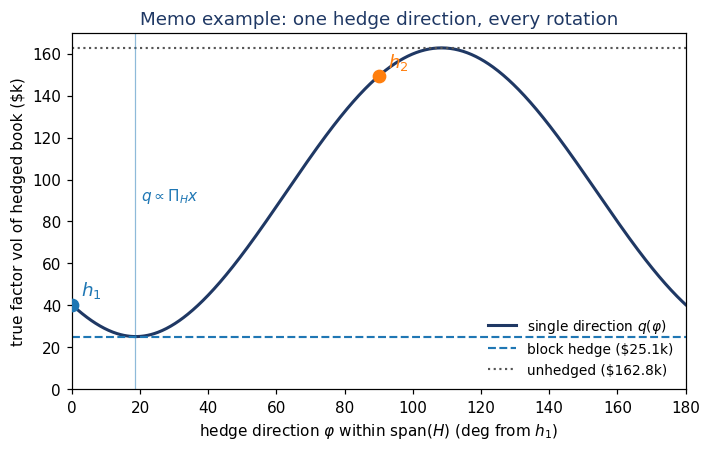

In [5]:
phi = np.linspace(0, np.pi, 721)
Q = H @ np.vstack([np.cos(phi), np.sin(phi)])               # (p, len(phi)) unit directions
R = x[:, None] - Q * (Q.T @ x)[None, :]                       # hedged books
fac_vol = np.sqrt(np.clip(np.einsum("pi,pq,qi->i", R, Sigma0, R), 0, None))

block_vol = np.sqrt(books["block hedge on H  (m=2)"] @ Sigma0 @ books["block hedge on H  (m=2)"])
unhedged_vol = np.sqrt(x @ Sigma0 @ x)
phi_star = np.arctan2(*(H.T @ x)[::-1]) % np.pi

print(f"single-direction factor vol over all phi: ${fac_vol.min():,.0f} .. ${fac_vol.max():,.0f}")
print(f"block hedge ${block_vol:,.0f}   unhedged ${unhedged_vol:,.0f}")
print(f"argmin phi = {np.degrees(phi[fac_vol.argmin()]):.2f} deg;  direction of Pi_H x = {np.degrees(phi_star):.2f} deg")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(np.degrees(phi), fac_vol / 1e3, color=THEME.navy, lw=2, label="single direction $q(\\varphi)$")
ax.axhline(block_vol / 1e3, color=C_F1, ls="--", lw=1.4, label=f"block hedge (${block_vol/1e3:.1f}k)")
ax.axhline(unhedged_vol / 1e3, color=THEME.gray, ls=":", lw=1.4, label=f"unhedged (${unhedged_vol/1e3:.1f}k)")
for deg, lab, col in [(0, "$h_1$", C_F1), (90, "$h_2$", C_F2)]:
    v = fac_vol[np.argmin(np.abs(np.degrees(phi) - deg))] / 1e3
    ax.plot(deg, v, "o", color=col, ms=8, zorder=5); ax.annotate(lab, (deg, v), xytext=(6, 6),
                                                                  textcoords="offset points", color=col, fontsize=12)
ax.axvline(np.degrees(phi_star), color=C_F1, lw=0.8, alpha=0.5)
ax.text(np.degrees(phi_star) + 2, 90, "$q\\propto\\Pi_H x$", color=C_F1, fontsize=10)
ax.set_xlabel("hedge direction $\\varphi$ within span$(H)$ (deg from $h_1$)")
ax.set_ylabel("true factor vol of hedged book ($k)")
ax.set_xlim(0, 180); ax.set_ylim(0, None); ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("Memo example: one hedge direction, every rotation", color=THEME.navy)
show(fig, "h4_fig1_single_direction_locus")

## 5 · Is the memo's draw typical?

The memo's example is a single draw. Below, the same model is redrawn 2,000 times
(Gaussian, $n=20$, same $B$), and the same hedges are run on each draw. For each draw
the output records:
- the block and labelled single-factor residuals;
- the pairwise and out-of-subspace errors;
- the data-side estimate $\sum_j\ell/\theta_j$.

As a sanity check on the first draw, the regression hedge coefficients are compared with
$H^\top x$.

In [6]:
N_OBS, N_REP, SEED = 20, 2_000, 20260930
rng = np.random.default_rng(SEED)
L_f, sd_z = np.linalg.cholesky(Sigma_f), np.sqrt(delta2)

rows = []
for rep in range(N_REP):
    Y = B @ (L_f @ rng.standard_normal((K, N_OBS))) + sd_z[:, None] * rng.standard_normal((p, N_OBS))
    Yc = Y - Y.mean(axis=1, keepdims=True)
    Hs, th, el = sample_pcs(Yc, K)
    Hs *= np.sign(np.diag(b_pop @ Hs))[None, :]
    if rep == 0:
        beta = regression_hedge_coefficients(Yc, x, Hs)
        print(f"regression hedge vs H'x, max abs diff: {np.abs(beta - Hs.T @ x).max():.2e}\n")
    g = subspace_geometry(b_pop, Hs)
    fv = lambda r: np.sqrt(max(r @ Sigma0 @ r, 0))
    rows.append({"block": fv(hedge(x, Hs)), "h1 only": fv(hedge(x, Hs, 1)),
                 "h2 only": fv(hedge(x, Hs[:, [1]])),
                 "pair_sum": g["pair_sum"], "oos_sum": g["oos_sum"],
                 "rot_sum": g["pair_sum"] - g["oos_sum"], "ell_theta": np.sum(el / th)})
mc = pd.DataFrame(rows)

memo = {"block": block_vol, "h1 only": np.sqrt(books["h1 only"] @ Sigma0 @ books["h1 only"]),
        "h2 only": np.sqrt(books["h2 only"] @ Sigma0 @ books["h2 only"]),
        "pair_sum": geo["pair_sum"], "oos_sum": geo["oos_sum"],
        "rot_sum": geo["pair_sum"] - geo["oos_sum"], "ell_theta": np.sum(ell / theta)}
summary = pd.DataFrame({"memo draw": memo,
                        "MC median": mc.median(),
                        "MC 10%": mc.quantile(0.10), "MC 90%": mc.quantile(0.90),
                        "memo percentile": {c: (mc[c] < memo[c]).mean() for c in mc}})
print(summary.to_string(float_format="{:,.3f}".format))
print(f"\nP(h1-only beats block) = {(mc['h1 only'] < mc['block']).mean():.1%}   "
      f"(unhedged factor vol ${unhedged_vol:,.0f})")

regression hedge vs H'x, max abs diff: 1.75e-10



            memo draw   MC median      MC 10%      MC 90%  memo percentile
block      25,099.671  30,826.892  12,848.922  66,370.244            0.382
h1 only    40,333.543  40,214.582  16,985.802  96,228.660            0.502
h2 only   149,366.552 157,942.623 126,646.690 162,672.419            0.273
pair_sum        0.874       1.144       0.897       1.512            0.085
oos_sum         0.741       1.065       0.816       1.272            0.062
rot_sum         0.132       0.063       0.007       0.309            0.713
ell_theta       0.528       0.478       0.388       0.579            0.727

P(h1-only beats block) = 5.9%   (unhedged factor vol $162,774)


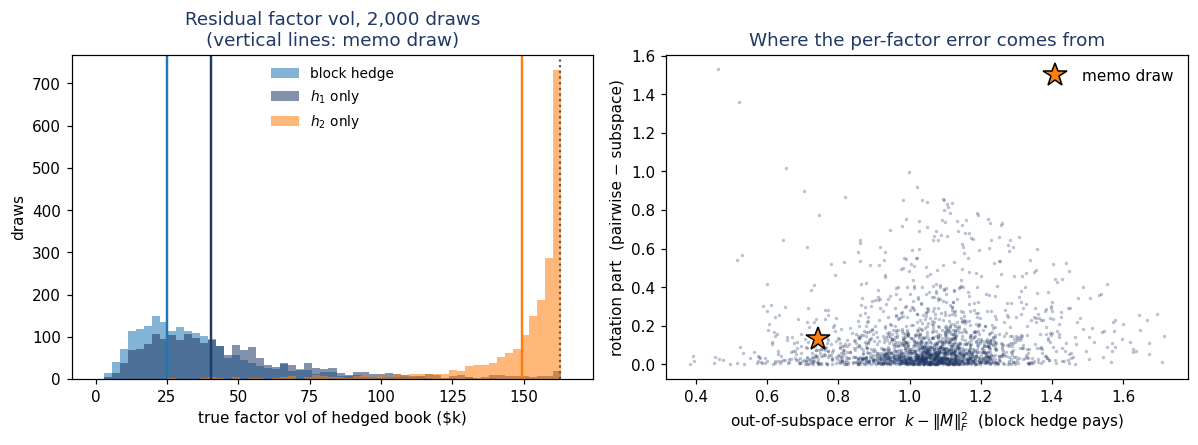

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
bins = np.linspace(0, unhedged_vol / 1e3 * 1.02, 60)
for col, c, lab in [("block", C_F1, "block hedge"), ("h1 only", THEME.navy, "$h_1$ only"),
                    ("h2 only", C_F2, "$h_2$ only")]:
    ax.hist(mc[col] / 1e3, bins=bins, color=c, alpha=0.55, label=lab)
    ax.axvline(memo[col] / 1e3, color=c, lw=1.6)
ax.axvline(unhedged_vol / 1e3, color=THEME.gray, ls=":", lw=1.4)
ax.set_xlabel("true factor vol of hedged book ($k)"); ax.set_ylabel("draws")
ax.set_title("Residual factor vol, 2,000 draws\n(vertical lines: memo draw)", color=THEME.navy)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.scatter(mc["oos_sum"], mc["rot_sum"], s=5, alpha=0.3, color=THEME.navy, lw=0)
ax.plot(memo["oos_sum"], memo["rot_sum"], "*", ms=16, color=C_F2, mec="k", label="memo draw")
ax.set_xlabel("out-of-subspace error  $k-\\|M\\|_F^2$  (block hedge pays)")
ax.set_ylabel("rotation part  (pairwise − subspace)")
ax.set_title("Where the per-factor error comes from", color=THEME.navy)
ax.legend(frameon=False)
fig.tight_layout()
show(fig, "h4_fig2_mc_context")

## 6 · Out-of-subspace estimate vs truth at this size

Corollary 1's $\sum_j\ell/\theta_j$ is an asymptotic statement ($p\to\infty$, $n$ fixed).
At $p=10$ it is only a rough guide, and this cell measures how rough.

In [8]:
ratio = mc["ell_theta"] / mc["oos_sum"]
print(f"sum ell/theta  /  true out-of-subspace:  median {ratio.median():.2f}   "
      f"10-90%: {ratio.quantile(.1):.2f} .. {ratio.quantile(.9):.2f}")
print(f"memo draw: {memo['ell_theta']:.3f} / {memo['oos_sum']:.3f} = {memo['ell_theta']/memo['oos_sum']:.2f}")
print(f"corr(ell/theta, oos) across draws: {np.corrcoef(mc['ell_theta'], mc['oos_sum'])[0,1]:.2f}")

sum ell/theta  /  true out-of-subspace:  median 0.45   10-90%: 0.35 .. 0.61
memo draw: 0.528 / 0.741 = 0.71
corr(ell/theta, oos) across draws: 0.21


## Summary

**On the memo's draw** ($1M equal-weight book; unhedged factor vol \$162.8k):

| hedge | true factor vol | factor variance left |
|---|---|---|
| block on $H$ ($m=2$) | \$25.1k | 2.4% |
| $h_1$ only | \$40.3k | 6.1% |
| $h_2$ only | \$149.4k | 84.2% |
| any single direction in span$(H)$ | \$25.1k … \$162.8k | 2.4% … 100% |

1. **What the block hedge leaves is out-of-subspace error.** The remaining true exposure
   is $\bar Br=(48.3\text{k},\,8.7\text{k})$, against $(313.7\text{k},\,3.5\text{k})$
   before hedging. Almost all of it is factor 1, sitting outside span$(H)$.
2. **A single-direction hedge can land anywhere between the block hedge and no hedge.**
   Aimed along $\Pi_Hx$ it reproduces the block hedge exactly. Aimed at the in-plane
   direction orthogonal to that, it trades nothing. This holds for every draw at $k=2$.
   Which labelled PC lands near which end is a rotation question.
3. **Rotation is a small part of the error in this model, not only in this draw.** Across
   2,000 redraws, the rotation part has median 0.06, against 1.07 for the
   out-of-subspace error. Factor 2 is weak: $p\mu_2=0.030$, well below
   $\bar\delta^2\approx0.099$. So $h_2$ mostly misses the true plane rather than rotating
   within it. On subspace error the memo draw is a favourable one (6th percentile). On
   hedge outcomes it is typical (38th–50th percentile).
4. **At $p=10$, $\sum_j\ell/\theta_j$ is not a reliable estimate of the out-of-subspace
   error.** It runs at about 0.45× the true value (10–90% range: 0.35–0.61), and its
   correlation with the truth across draws is only 0.21. Corollary 1 is a large-$p$
   statement, and the running example is too small for it to be quoted as a number.

If the memo needs rotation error to be visible in the running example, factor 2 has to be
strengthened: a larger $\sigma_{\text{style}}$, or style loadings with more spread.